In [1]:
import config
import torch
import sys
sys.path.append('../util')
sys.path.append('../others_networks')
sys.path.append('../UMergeNet')
from Trainer import Trainer
from util import show_dataset_prev
from GenericDatasetReader import get_datasets
from util import run_profiler
from UMergeNet import ConvType, UMergeNet

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
result_path = './UMergeNet/'



In [2]:
num_classes  = config.num_classes
in_channels  = config.in_channels
out_channels = 1

train_loader, test_loader, val_loader = get_datasets(dataset_dir=config.dataset_path, 
                                              resolution=config.dataset_resolution, 
                                              batch_size=config.batch_size)

torch.Size([16, 3, 224, 224]) torch.Size([16, 1, 224, 224])
8701 97 98


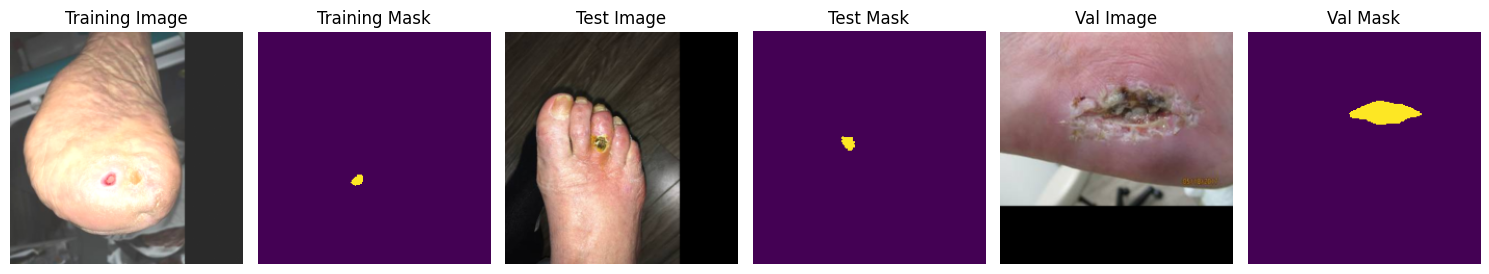

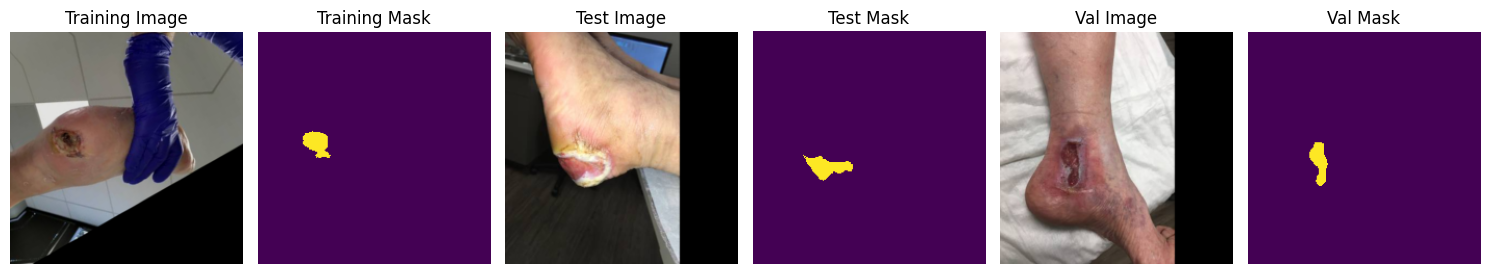

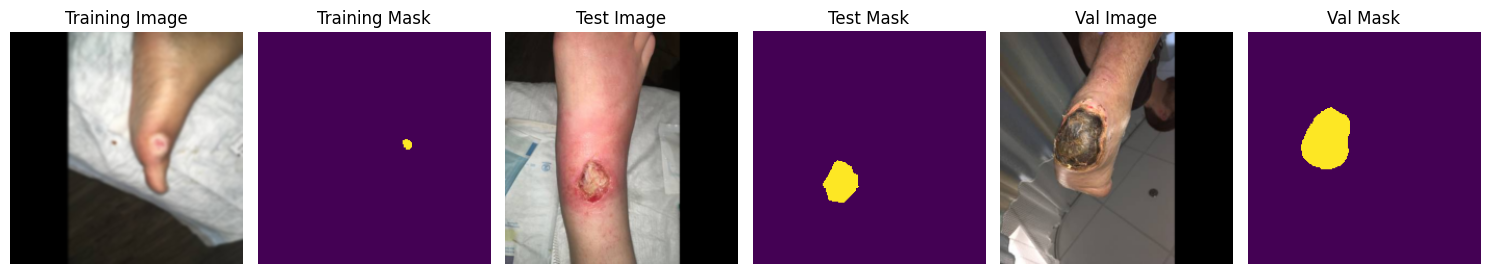

In [3]:
for (images_train, masks_train), (images_test, masks_test) in zip(train_loader, test_loader):
    print(images_train.shape, masks_train.shape)
    break

print(len(train_loader.dataset), len(test_loader.dataset), len(val_loader.dataset))

show_dataset_prev(train_loader, test_loader, val_loader, num_images=3)

In [4]:
def train(model, model_name=None, epochs=300, re_evaluate=True):
    model_filename = f'{model_name}-epochs{epochs}.pth'

    
    trainer = Trainer(num_classes=num_classes,
                    model_filename=model_filename, 
                    model_dir=result_path, 
                    save_xlsx=True)
    model = trainer.train(model, train_loader, val_loader, test_loader,
                            num_epochs=epochs, 
                            verbose=1, 
                            save_every=5, 
                            learning_rate=1e-3,
                            continue_from_last=True,
                            # we are re-evaluating after loading the model 
                            # because we refactored the code and want to see the new results
                            re_evaluate=re_evaluate)
    model.to(device)
    return trainer.get_best_test_stats()



In [5]:
model = UMergeNet(in_channels=in_channels, out_channels=out_channels, conv_type=ConvType.Axial)
run_profiler(model, test_loader, model_name='UMergeNet', num_steps=1)

Profiling results saved to: ./tb_profiler_streams/UMergeNet_run_3
-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                                   Name    Self CPU %      Self CPU   CPU total %     CPU total  CPU time avg     Self CUDA   Self CUDA %    CUDA total  CUDA time avg    # of Calls  
-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                        model_inference         0.00%       0.000us         0.00%       0.000us       0.000us     567.996ms      3620.49%     567.996ms     113.599ms             5  
                                        model_inference         1.58%       5.965ms        63.61%     240.226ms     240.226ms       0.000us  

In [ ]:
#Then install tensorboard with profiler and start with --logdir parameter

#pip install tensorboard torch-tb-profiler
#tensorboard --logdir tb_profiler_streams 

#Views -> Trace